In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [ ]:
data = pd.read_csv('fmreg_data_std_98.csv')
data.head()

,firm_id,date,grossprofit,earnsurprise,sue,fscore,xfin,volatility,accruals,inssell,booktomarket,momentum,ret
0,06BBF,2021-02-09,0.869171,-0.108093,-0.769057,-0.265646,0.734063,-1.033388,-1.452731,0.787249,-0.535024,0.324030,-0.524228
1,06D6S,2021-02-09,-0.452492,0.629503,-1.176238,-0.016744,-1.176420,-0.330665,0.032829,0.560791,-1.354370,-0.759050,-0.634935
2,0BRQB,2021-02-09,-1.638408,0.383505,-0.779240,-0.144920,-1.038177,1.963128,1.125647,1.596075,-0.758358,0.229012,-0.613698
3,0HNLC,2021-02-09,-1.319892,-1.643347,2.956599,-0.715291,0.076356,-0.252871,0.905934,-0.637580,1.887648,1.158095,-0.345061
4,0S0TH,2021-02-09,-1.552097,-0.060631,-0.254945,-0.452020,-0.969741,0.068686,0.344827,0.486895,-1.316713,0.384753,-0.536383


In [ ]:
data.columns

Index(['firm_id', 'date', 'grossprofit', 'earnsurprise', 'sue', 'fscore',
       'xfin', 'volatility', 'accruals', 'inssell', 'booktomarket', 'momentum',
       'ret'],
      dtype='object')

In [ ]:
data["date"] = pd.to_datetime(data["date"])
data["month"] = data["date"].dt.to_period("M")

In [ ]:
y = data["ret"]

factors = [
    "grossprofit", "earnsurprise", "sue", "fscore",
    "xfin", "volatility", "accruals", "inssell",
    "booktomarket", "momentum"
]

**Part 1 Univariate Analysis**

In [ ]:
betas = []

for m, g in data.groupby("month"):

    row = {"month": m}

    for f in factors:
        g_f = g.dropna(subset=["ret", f])

        X = sm.add_constant(g_f[[f]])
        y = g_f["ret"]
        model = sm.OLS(y, X).fit()

        row[f] = model.params.get(f, np.nan)
        row[f"r2_{f}"] = model.rsquared
        row[f"n_obs_{f}"] = len(g_f)

    betas.append(row)

beta_df = pd.DataFrame(betas).sort_values("month")

In [ ]:
results = []

T = beta_df.shape[0]

for f in factors:
    series = beta_df[f].dropna()

    mean_beta = series.mean()
    std_beta = series.std(ddof=1)

    t_stat = mean_beta / (std_beta / np.sqrt(len(series)))

    results.append({
        "factor": f,
        "beta_mean": mean_beta,
        "t_stat": t_stat,
        "avg_r2": beta_df[f"r2_{f}"].mean(),
        "avg_n_obs": beta_df[f"n_obs_{f}"].mean(),
    })

results_df = pd.DataFrame(results).set_index("factor")
results_df.sort_values("beta_mean", ascending=False, inplace=True)
results_df.round(4)

,beta_mean,t_stat,avg_r2,avg_n_obs
factor,,,,
momentum,0.0157,7.0353,0.0447,200.0
earnsurprise,0.0155,9.8548,0.0195,200.0
sue,0.0138,7.6186,0.0210,200.0
accruals,0.0077,3.8267,0.0116,200.0
grossprofit,0.0042,2.7054,0.0071,200.0
booktomarket,0.0033,2.2794,0.0055,200.0
fscore,0.0029,1.5718,0.0089,200.0
xfin,-0.0084,-4.5547,0.0121,200.0
volatility,-0.0143,-6.2233,0.0240,200.0


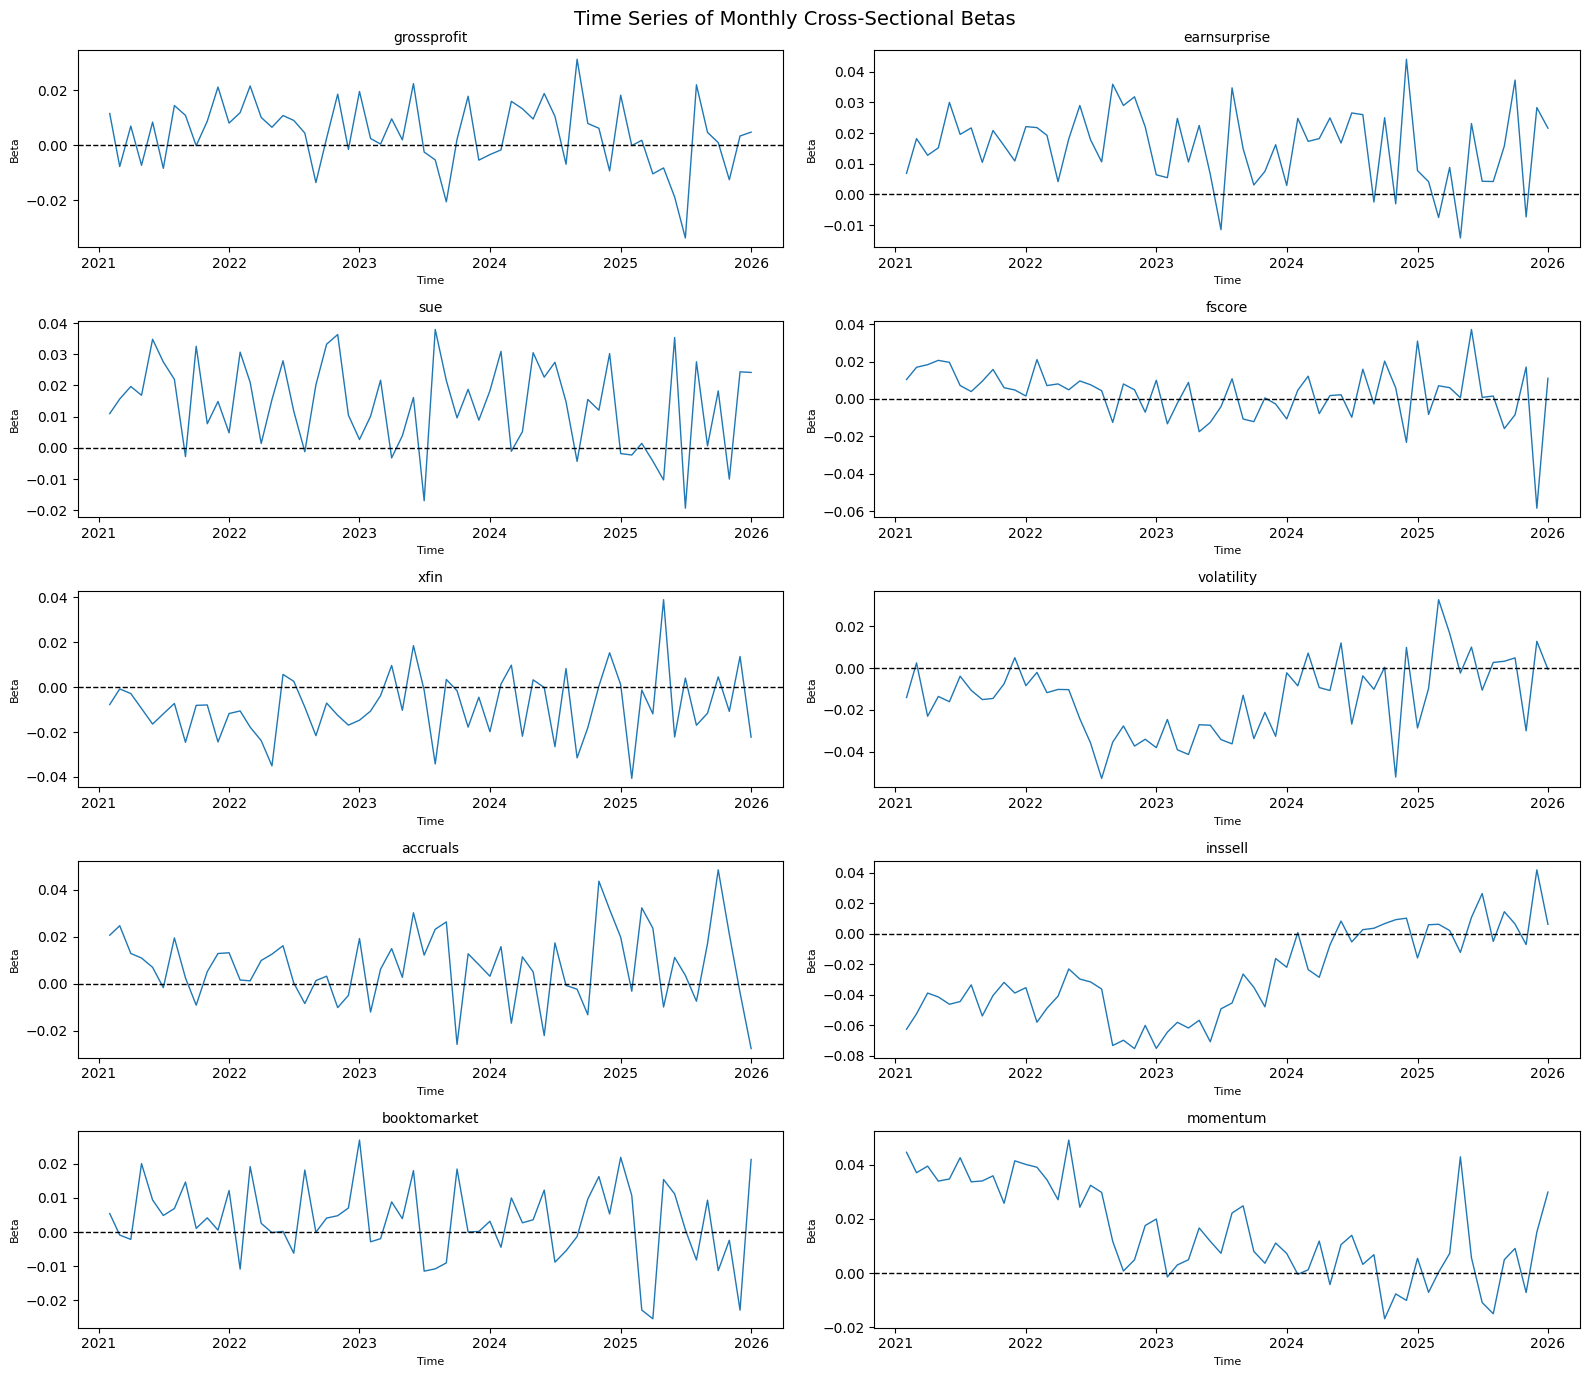

In [ ]:
beta_df = beta_df.sort_values("month")

fig, axes = plt.subplots(5, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()
fig.suptitle("Time Series of Monthly Cross-Sectional Betas", fontsize=14)

for i, f in enumerate(factors):
    ax = axes[i]

    # convert period to timestamp for proper time axis
    x = beta_df["month"].dt.to_timestamp()

    ax.plot(x, beta_df[f], linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_title(f"{f}", fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("Beta", fontsize=8)

    # finance standard: yearly ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [ ]:
positive = []

for f in factors:
    series = beta_df[f].dropna()

    positive_fraction = (series >= 0).mean()

    positive.append({
        "factor": f,
        "positive_fraction": positive_fraction
    })

positive_df = pd.DataFrame(positive).set_index("factor")
positive_df.sort_values("positive_fraction", ascending=False, inplace=True)
positive_df.round(4)

,positive_fraction
factor,
earnsurprise,0.9000
momentum,0.8333
sue,0.8000
accruals,0.7167
fscore,0.6833
grossprofit,0.6667
booktomarket,0.6500
xfin,0.2667
inssell,0.2667


**Part 1 Multivariate Analysis**

In [ ]:
betas = []

for m, g in data.groupby("month"):
    g = g.dropna(subset=["ret"] + factors)

    X = sm.add_constant(g[factors])
    y = g["ret"]

    model = sm.OLS(y, X).fit()

    row = {
        "month": m,
        "n_obs": len(g),
        "r2": model.rsquared
    }

    for f in factors:
        row[f] = model.params.get(f, np.nan)

    betas.append(row)

beta_df = pd.DataFrame(betas).sort_values("month")

In [ ]:
results = []

T = beta_df.shape[0]
total_n_obs = data.dropna(subset=["ret"] + factors).shape[0]

for f in factors:
    series = beta_df[f].dropna()

    mean_beta = series.mean()
    std_beta = series.std(ddof=1)

    t_stat = mean_beta / (std_beta / np.sqrt(T))

    results.append({
        "factor": f,
        "beta_mean": mean_beta,
        "t_stat": t_stat,
        "avg_r2": np.nan,
        "avg_n_obs": np.nan,
    })

results_df = pd.DataFrame(results).set_index("factor")
results_df.round(4)

results_df.loc["model"] = {
    "beta_mean": np.nan,
    "t_stat": np.nan,
    "avg_r2": beta_df["r2"].mean(),
    "avg_n_obs": beta_df["n_obs"].mean(),
}
results_df.sort_values("beta_mean", ascending=False, inplace=True)
results_df.round(4).fillna("—")

,beta_mean,t_stat,avg_r2,avg_n_obs
factor,,,,
momentum,0.0147,6.1364,—,—
earnsurprise,0.0114,5.9413,—,—
accruals,0.0083,4.5543,—,—
sue,0.0052,2.5663,—,—
grossprofit,0.0042,2.7846,—,—
fscore,0.0038,2.1132,—,—
booktomarket,0.0032,2.4243,—,—
xfin,-0.0096,-5.5561,—,—
volatility,-0.014,-6.184,—,—


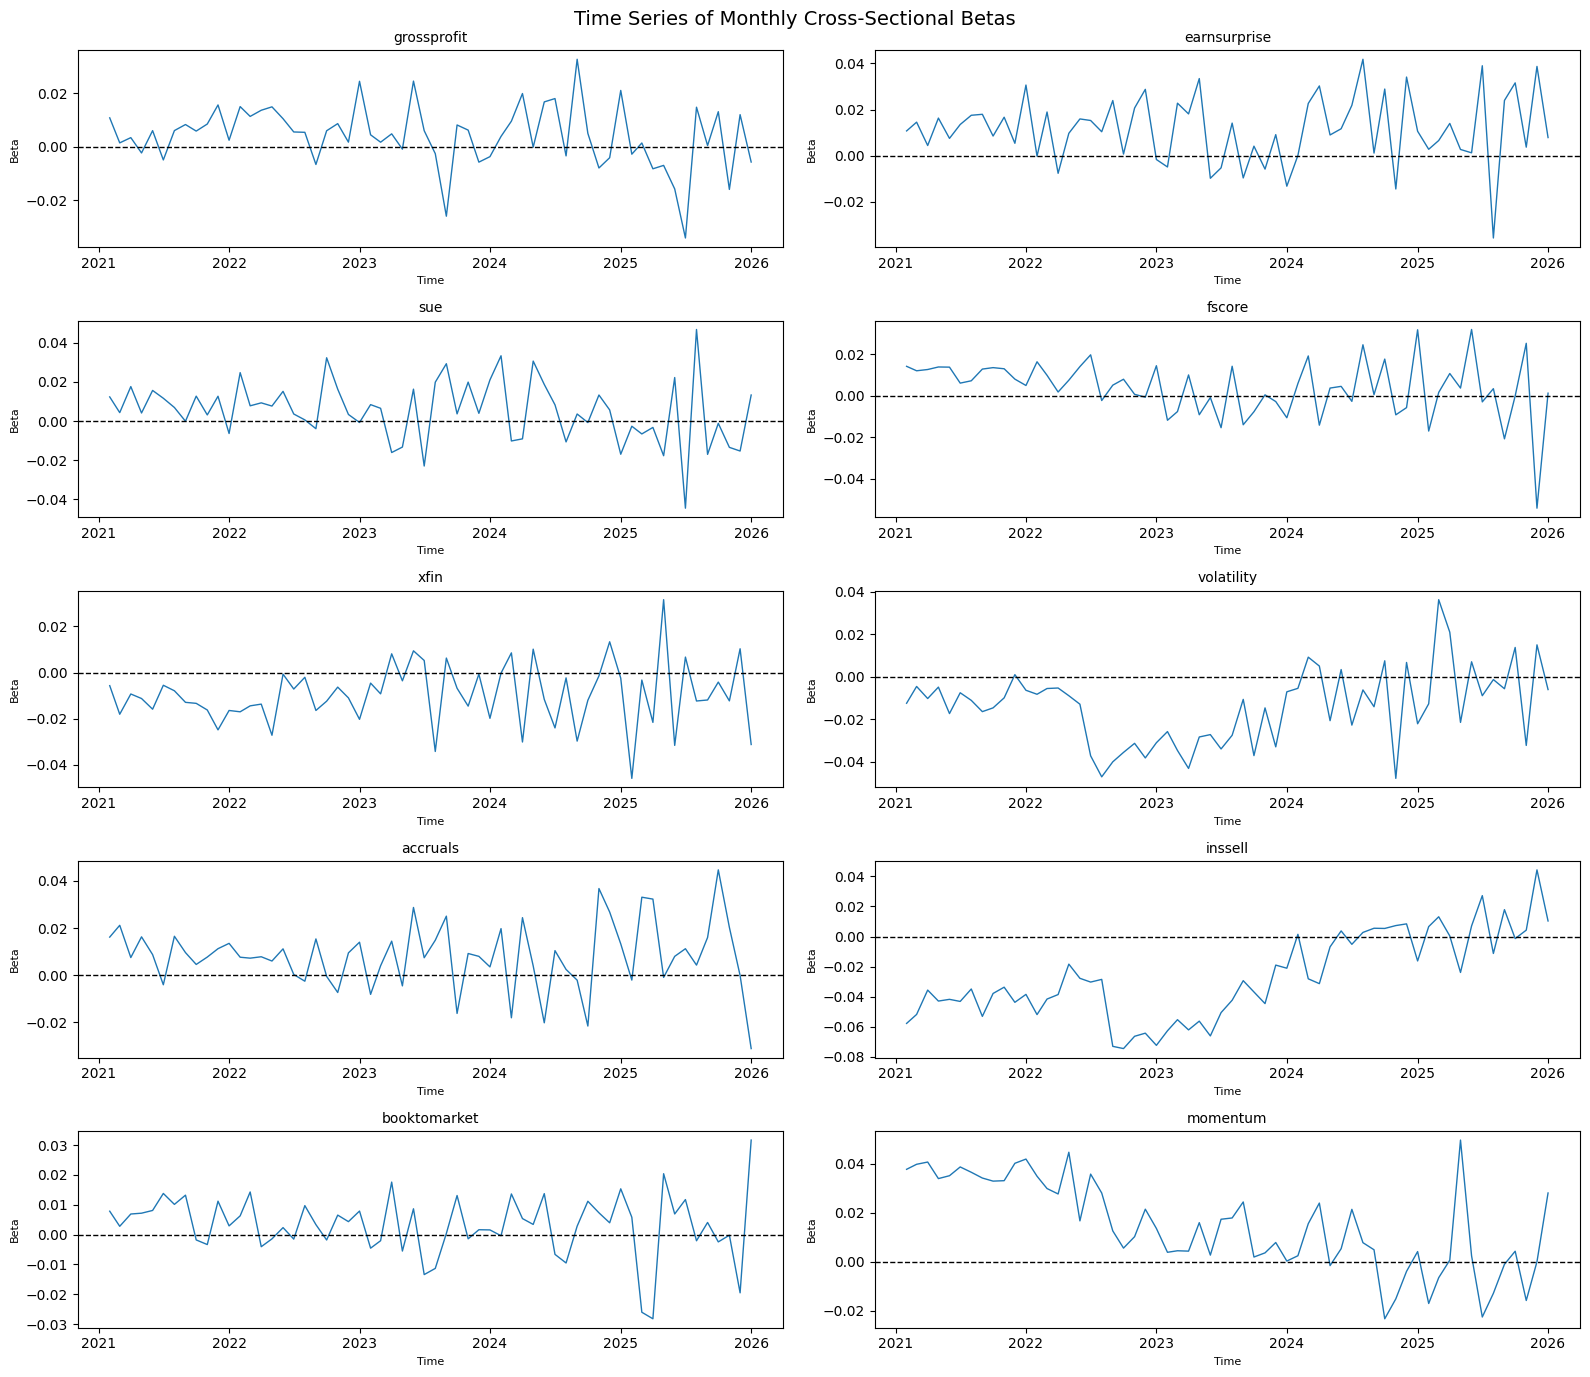

In [ ]:
beta_df = beta_df.sort_values("month")

fig, axes = plt.subplots(5, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()
fig.suptitle("Time Series of Monthly Cross-Sectional Betas", fontsize=14)

for i, f in enumerate(factors):
    ax = axes[i]

    # convert Period → timestamp for proper time axis
    x = beta_df["month"].dt.to_timestamp()

    ax.plot(x, beta_df[f], linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_title(f"{f}", fontsize=10)
    ax.tick_params(axis='x', labelbottom=True)

    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("Beta", fontsize=8)

    # finance standard: yearly ticks
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

**Part 1 Sharpe Ratio**

In [ ]:
results_df.drop("model", inplace=True)
results_df["sharpe_ratio"] = results_df["t_stat"]/np.sqrt(beta_df.shape[0])

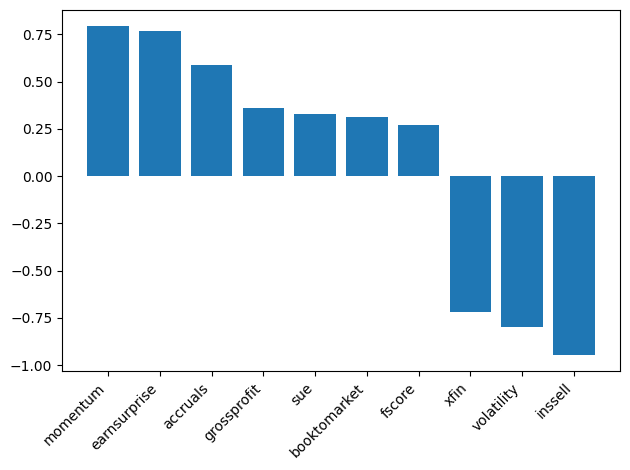

In [ ]:
results_df.sort_values("sharpe_ratio", ascending=False, inplace=True)
plt.bar(results_df.index, results_df["sharpe_ratio"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()